In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import pingouin as pg
import matplotlib
from hyppo.independence import Dcorr

# Независимость

1. Найти коэффициенты корреляции баллов ЕГЭ и частные коэффициенты корреляции и сделать выводы
о структуре их зависимости.

In [2]:
ege_set = pd.read_csv('matprak5_dataset.csv', sep=',', encoding='cp1251')
ege_set = ege_set.rename(columns={
    "Оценка.1" : "1",
    "Оценка.2" : "2",
    "Оценка.3" : "3",
    "Оценка.4" : "4"
})


In [3]:
pg.pairwise_corr(ege_set, columns = ege_set.columns)

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,1,2,pearson,two-sided,1449,0.511660,"[0.47, 0.55]",1.727267e-97,5.76e+93,1.000000
1,1,3,pearson,two-sided,1449,0.432463,"[0.39, 0.47]",4.221979e-67,3.067e+63,1.000000
2,1,4,pearson,two-sided,1449,0.123863,"[0.07, 0.17]",2.255482e-06,2337.442,0.997248
3,2,3,pearson,two-sided,1457,0.436564,"[0.39, 0.48]",7.453913e-69,1.704e+65,1.000000
4,2,4,pearson,two-sided,1473,0.218213,"[0.17, 0.27]",2.451500e-17,1.193e+14,1.000000
5,3,4,pearson,two-sided,1457,0.254438,"[0.21, 0.3]",5.812641e-23,4.301e+19,1.000000


In [9]:
pg.pairwise_corr(ege_set, columns = ege_set.columns, covar = "1")


,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,2,3,pearson,['1'],two-sided,1449,0.277743,"[0.23, 0.32]",4.650154e-27
1,2,4,pearson,['1'],two-sided,1449,0.190870,"[0.14, 0.24]",2.401950e-13
2,3,4,pearson,['1'],two-sided,1449,0.225276,"[0.18, 0.27]",4.074510e-18


In [8]:
pg.pairwise_corr(ege_set, columns = ege_set.columns, covar = "2")

,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,1,3,pearson,['2'],two-sided,1449,0.270561,"[0.22, 0.32]",1.036376e-25
1,1,4,pearson,['2'],two-sided,1449,0.009765,"[-0.04, 0.06]",7.104231e-01
2,3,4,pearson,['2'],two-sided,1457,0.179630,"[0.13, 0.23]",5.034811e-12


In [10]:
pg.pairwise_corr(ege_set, columns = ege_set.columns, covar = "3")

,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,1,2,pearson,['3'],two-sided,1449,0.398050,"[0.35, 0.44]",3.592188e-56
1,1,4,pearson,['3'],two-sided,1449,0.015521,"[-0.04, 0.07]",5.550894e-01
2,2,4,pearson,['3'],two-sided,1457,0.127329,"[0.08, 0.18]",1.092295e-06


In [11]:
pg.pairwise_corr(ege_set, columns = ege_set.columns, covar = "4")

,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,1,2,pearson,['4'],two-sided,1449,0.500366,"[0.46, 0.54]",1.373235e-92
1,1,3,pearson,['4'],two-sided,1449,0.417799,"[0.37, 0.46]",2.913855e-62
2,2,3,pearson,['4'],two-sided,1457,0.403096,"[0.36, 0.45]",5.356335e-58


In [4]:
pg.pairwise_corr(ege_set, columns = ["1","4"], covar = ["2","3"])

,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,1,4,pearson,"['2', '3']",two-sided,1449,-0.040675,"[-0.09, 0.01]",0.121971


In [5]:
pg.pairwise_corr(ege_set, columns = ["2", "3"], covar = ["1", "4"])

,X,Y,method,covar,alternative,n,r,CI95,p_unc
0,2,3,pearson,"['1', '4']",two-sided,1449,0.24545,"[0.2, 0.29]",2.692975e-21


2. Для распределений, изображенных на рисунке 1 (сгенерируйте выборки самостоятельно, размер вы-
борок 50 или 100), сравните критерии Секея-Риццо, Кендалла и хи-квадрат. Для распределения хи-
квадрат ячейки предлагается выбирать, деля данные по каждой из строк на равные фрагменты. Учтите, что общее число ячеек должно быть много меньше, чем √n, где n – число наблюдений!

![опа картинка](matprak5_pic.png)

In [ ]:
def chi2_sec(X, Y, y_line = -0.5, x_lines = [-0.5, 0.5]):
    X = np.asarray(X)
    Y = np.asarray(Y)
    table = [[np.sum((X < x_lines[0]) & (Y > y_line)), np.sum((X < x_lines[1]) & (Y > y_line) & (X >= x_lines[0])), np.sum((X > x_lines[1]) & (Y > y_line))],
            [np.sum((X < x_lines[0]) & (Y <= y_line)), np.sum((X < x_lines[1]) & (Y <= y_line) & (X >= x_lines[0])), np.sum((X > x_lines[1]) & (Y <= y_line))]]
    return stats.chi2_contingency(table)

   

In [25]:
crits = [[Dcorr().test, "Szekely-Rizzo"],
         [stats.kendalltau, "Kendall"],
         [chi2_sec, "Chi2"]]


In [47]:
def criterion_id(pval_gen, data_gen, label_custom = None, output = True, k = 100):
    p_val = []
    a = 0.05
    for _ in range(k):
        x_data, y_data = data_gen()
        pval = pval_gen(x_data, y_data)[1]
        p_val.append(pval)
    ecdf = stats.ecdf(p_val)
    if output:
        sns.ecdfplot(p_val, label = f'{label_custom}: power = {ecdf.cdf.evaluate(a)}')
    return ecdf.cdf.evaluate(a)


def compare_crit(gen, title = None, y_line = -0.5, x_lines = [-0.5, 0.5]):
    crits = [[Dcorr().test, "Szekely-Rizzo"],
         [stats.kendalltau, "Kendall"],
         [partial(chi2_sec, y_line = y_line, x_lines = x_lines), "Chi2"]]
    for crit in crits:
        pval_gen = crit[0]
        label = crit[1]
        power = criterion_id(pval_gen, gen, label_custom = label)
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    plt.title(title)
    plt.legend()
    plt.show()


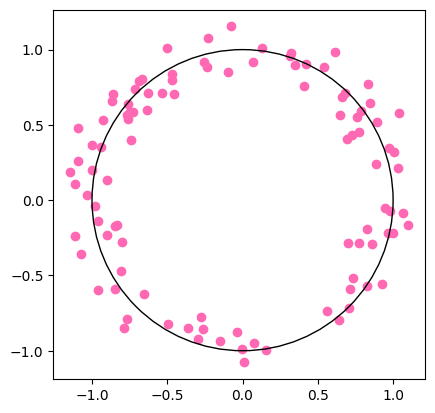

In [5]:
def circle_gen(n = 100):
    epsilon = 0.01
    theta = stats.uniform.rvs(scale = 2*np.pi, size = n)
    r = stats.norm.rvs(loc = 1, scale = np.sqrt(epsilon), size = n)
    x_data = r*np.cos(theta)
    y_data = r*np.sin(theta)
    return x_data, y_data

fig, ax = plt.subplots()
x, y = circle_gen(n = 100)
ax.scatter(x,y, marker='o',color='hotpink')
circle = matplotlib.patches.Circle((0,0), 1, fill = False, color = 'black')
ax.add_patch(circle)
ax.set_aspect('equal')
plt.show()

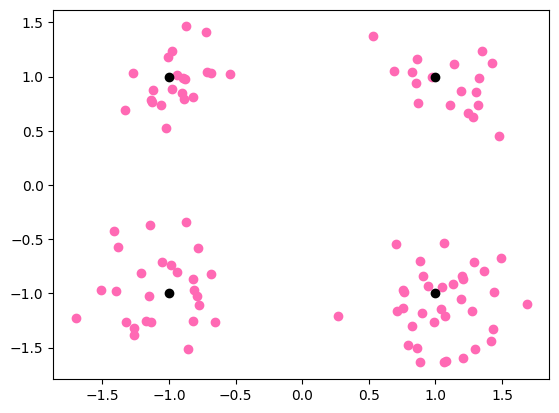

In [6]:
def clouds_gen(n = 100):
    epsilon = 0.09
    x_data = []
    y_data = []
    for _ in range(n):
        center = np.random.choice(4)
        center = [(1,1),(-1,1),(1,-1),(-1,-1)][center]
        x_data.append(stats.norm.rvs(loc = center[0], scale = np.sqrt(epsilon)))
        y_data.append(stats.norm.rvs(loc = center[1], scale = np.sqrt(epsilon)))
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    return x_data, y_data

x, y = clouds_gen(100)
plt.scatter(x,y, marker='o', color = 'hotpink')
plt.plot(1,1, 'o', color = 'black')
plt.plot(-1,1, 'o', color = 'black')
plt.plot(1,-1,'o', color = 'black')
plt.plot(-1,-1,'o', color = 'black')
plt.show()

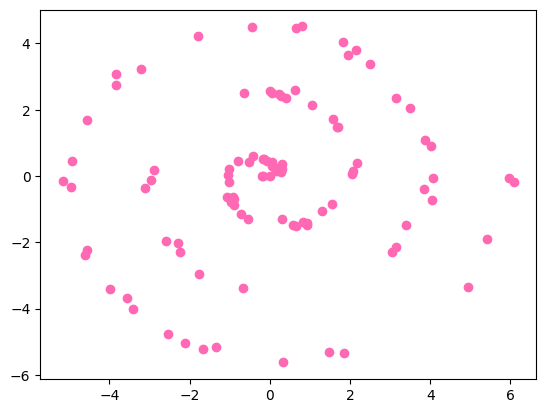

In [7]:
def spiral_gen(n=100):
    epsilon = 0.01
    theta = stats.uniform.rvs(scale = 6*np.pi, size = n)
    error = stats.norm.rvs(scale = np.sqrt(epsilon), size = n)
    r = theta/np.pi + error
    x_data = r*np.cos(theta)
    y_data = r*np.sin(theta)
    return x_data, y_data


x,y = spiral_gen(100)
plt.scatter(x,y, marker='o', color='hotpink')


In [44]:
x_data, y_data = circle_gen(n= 100)
chi2_sec(x_data, y_data)

Chi2ContingencyResult(statistic=np.float64(7.329686467084446), pvalue=np.float64(0.025608185473586058), dof=2, expected_freq=array([[29.11, 18.46, 23.43],
       [11.89,  7.54,  9.57]]))

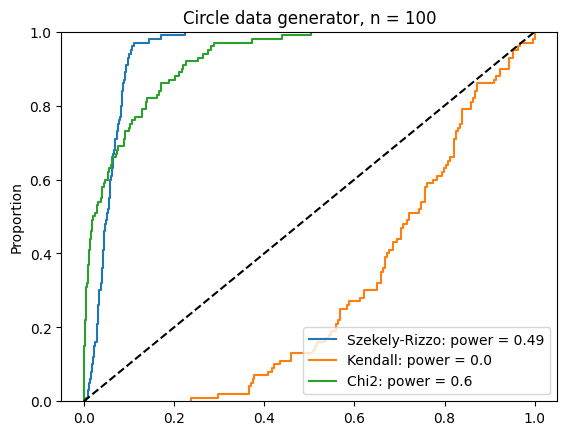

In [48]:
compare_crit(circle_gen, title=f"Circle data generator, n = {100}")

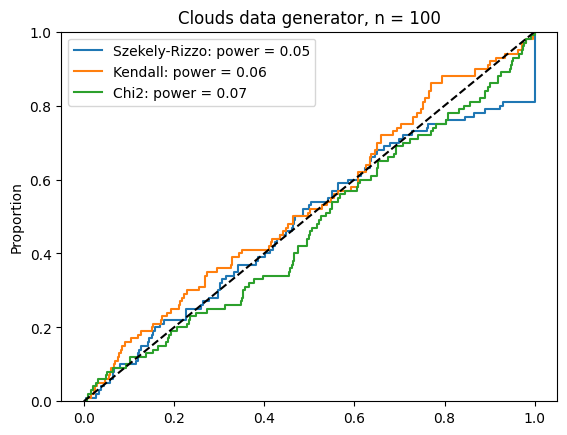

In [49]:
compare_crit(clouds_gen, title=f"Clouds data generator, n = {100}", y_line = 0, x_lines = [-1, 1])

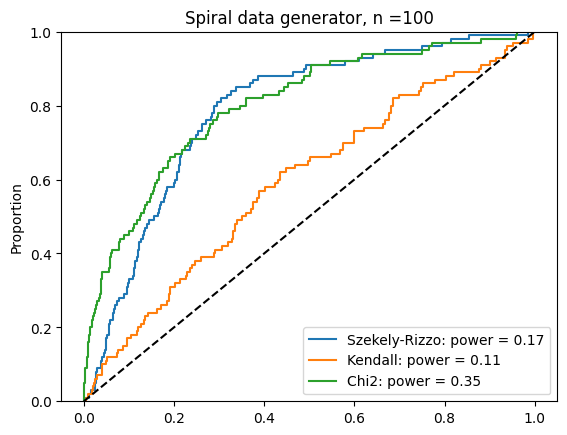

In [50]:
compare_crit(spiral_gen, title=f'Spiral data generator, n ={100}')

3. Сравните критерии Смирнова, Пирсона, Кендалла, Спирмена и Секея-Риццо на выборках 
1) Yi = X2 i +εi, Xi ∼ R[−1, 2], εi ∼ N (0, 0.5), 
2) Yi = sin Xi + εi, Xi ∼ R[0, 2π], εi ∼ N (0, 0.5).

In [14]:


def gen1(n = 50):
    x_data = stats.uniform.rvs(loc = -1, scale = 2, size = n)
    y_data = x_data **2 + stats.norm.rvs(scale = np.sqrt(0.5), size = n)
    return x_data, y_data

def gen2(n=50):
    x_data = stats.uniform.rvs(loc = -2*np.pi, scale = 4*np.pi, size = n)
    y_data = np.sin(x_data) + stats.norm.rvs(scale = np.sqrt(0.05), size = n)
    return x_data, y_data

In [7]:
def ks_ind_stat(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    n = len(X)
    
    max_diff = 0
    for i, x in enumerate(X):
        F_x = np.sum(X <= x) / n
        
        for j, y in enumerate(Y):
            G_y = np.sum(Y <= y) / n
            H_xy = np.sum((X <= x) & (Y <= y)) / n
            
            diff = np.abs(H_xy - F_x * G_y)

            max_diff = max(diff, max_diff)
    
    return np.sqrt(n)*max_diff


def ks_ind_montecarlo(n = 500, N = 100):
    T = []
    for _ in range(N):
        x = stats.uniform.rvs(size = n)
        y = stats.uniform.rvs(size = n)
        T.append(ks_ind_stat(x,y))
    return sorted(T)

def ks_ind(x, y, T):
    N = len(T)
    stat = ks_ind_stat(x, y)
    k = 0
    for i in range(N):
        if T[i] < stat:
            k+=1
        else:
            break
    pval = 1 - k/N
    return stat, pval

In [15]:
#НЕ ЗАПУСКАТЬ
T_ks_ind = ks_ind_montecarlo()

with open('ks_ind_mc.txt', 'w') as f:
    f.write('\n'.join(map(str, T_ks_ind)))

In [5]:
with open('ks_ind_mc.txt', 'r') as f:
    T_ks_ind_file = [float(line.strip()) for line in f if line.strip()]

In [8]:
crits = [[Dcorr().test, "Szekely-Rizzo"],
         [stats.kendalltau, "Kendall"],
         [partial(ks_ind, T = T_ks_ind_file), "KS"],
         [stats.pearsonr, "Pearson"],
         [stats.spearmanr, "Spearman"]]

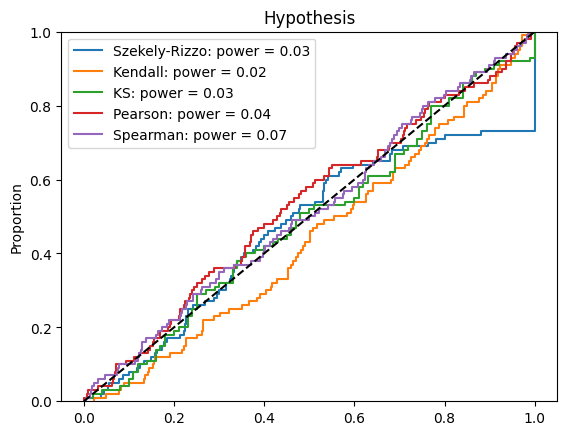

In [17]:
def gen0(n=50):
    #x_data = stats.norm.rvs(size=n)
    #y_data = stats.expon.rvs(scale = 3, size = n)
    x_data = stats.uniform.rvs(size=n)
    y_data = stats.uniform.rvs(size = n)
    return x_data, y_data

n = 100
compare_crit(partial(gen0, n =n), title= "Hypothesis")

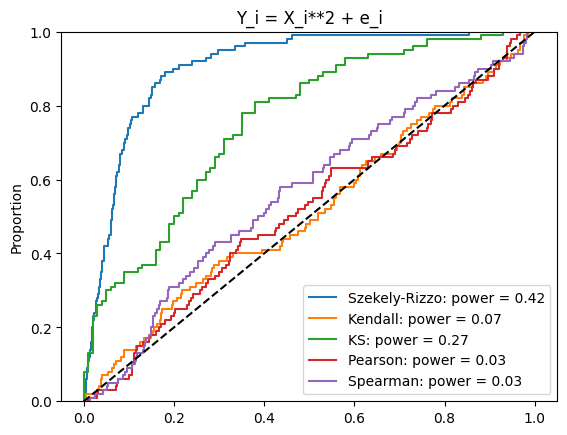

In [11]:
n = 100
compare_crit(partial(gen1, n = n), title=f"Y_i = X_i**2 + e_i")

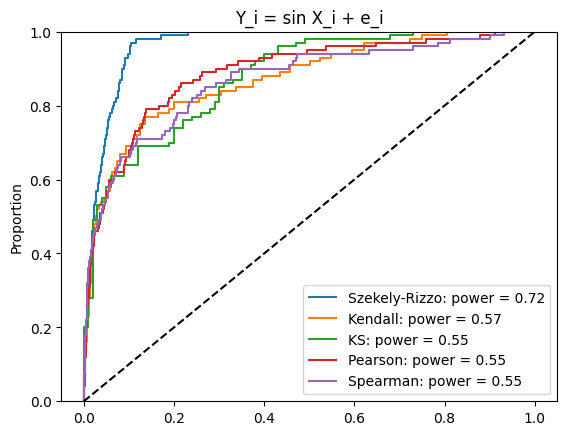

In [16]:
n = 30
compare_crit(partial(gen2, n = n), title="Y_i = sin X_i + e_i")

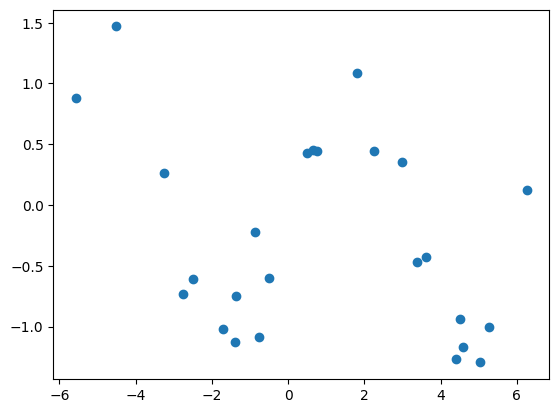

In [18]:
x_data, y_data = gen2(n=25)
plt.scatter(x_data, y_data)